# 📘 Notebook 03: Learned Positional Embeddings

In this notebook, we explore **learned positional embeddings**, where each position has a dedicated vector that is **learned** during training.

This approach is widely used in modern models like **BERT**, **GPT**, and others that prefer flexibility over the deterministic sinusoidal approach.

---


## 🧠 Why Use Learned Positional Embeddings?

Unlike sinusoidal (which are fixed and mathematical), learned positional embeddings:

- Are **trained along with the rest of the model**
- Can adapt to data distribution
- Are more flexible for fine-tuning tasks

They do not generalize to longer sequences unless trained explicitly — but that's often acceptable for fixed-length transformers.

---


In [1]:
import torch
import torch.nn as nn

# Configuration
seq_len = 10
embedding_dim = 16

# Positional embedding layer
pos_embed = nn.Embedding(num_embeddings=seq_len, 
                        embedding_dim=embedding_dim)

# Get all positional embeddings (for each position 0 to 9)
poistions = torch.arange(seq_len)
learned_pe = pos_embed(poistions)

print(f"Shape : {learned_pe.shape}")
print(f"Vector for position 0 :\n{learned_pe[0]}")

Shape : torch.Size([10, 16])
Vector for position 0 :
tensor([-0.3185,  0.6981, -1.0911, -1.3922,  0.8632,  1.4338, -0.5995,  1.8094,
         0.8384,  0.3177, -1.6204, -1.3523,  0.7048, -0.4622,  0.9153, -0.9781],
       grad_fn=<SelectBackward0>)


## 🧪 What Happens Here?

We created a trainable embedding matrix of shape:


- Each position `0..9` gets a unique vector
- These vectors are updated during backpropagation, like token embeddings
- This is used in most modern LLMs where the model has **fixed context length**

---


Text(0, 0.5, 'Positions Index')

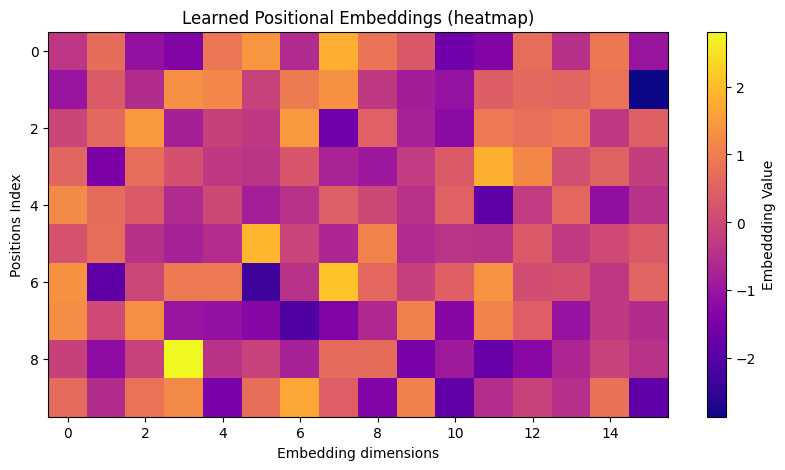

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.imshow(learned_pe.detach().numpy(), aspect="auto", cmap='plasma')
plt.colorbar(label = "Embeddding Value")
plt.title("Learned Positional Embeddings (heatmap)")
plt.xlabel("Embedding dimensions")
plt.ylabel("Positions Index")


## ✅ Summary

- Learned positional embeddings give **each position its own vector**
- They are **trainable parameters**, unlike sinusoidal embeddings
- Widely used in modern models like BERT, GPT, RoBERTa, etc.
- Can handle **non-uniform patterns** in language better

---

🔜 Next Notebook: **Combining Token + Position Embeddings** for final model input!
